In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from netCDF4 import Dataset

In [2]:
def convertir_tiempo_pisco_v2(ds):
    ds = ds.copy()

    t = ds["T"].values

    # El archivo usa "months since 1960-01-01"
    # Valores como 252.5, 253.5, ...
    # Redondeamos al mes entero correspondiente.
    meses_desde_1960 = np.floor(t).astype(int)

    fechas = pd.to_datetime("1960-01-01") + pd.to_timedelta(
        meses_desde_1960 * 30,
        unit="D"
    )

    # Mejor: reconstruir como calendario mensual real
    fechas = pd.DatetimeIndex([
        pd.Timestamp("1960-01-01") + pd.DateOffset(months=int(m))
        for m in meses_desde_1960
    ])

    ds = ds.assign_coords(time=("T", fechas))
    ds = ds.swap_dims({"T": "time"})
    ds = ds.drop_vars("T")

    return ds

In [3]:

pisco_mensual_v3_path = "../Data/PISCOp_m_3.nc"
pisco_mensual_v2_path = "../Data/PISCOp_m_2_1.nc"

ds_v3 = xr.open_dataset(
    pisco_mensual_v3_path,
    engine="netcdf4",
    decode_times=True,
    mask_and_scale=True
)

ds_v2 = xr.open_dataset(
    pisco_mensual_v2_path,
    engine="netcdf4",
    decode_times=False,
    mask_and_scale=True
)


ds_v3

<xarray.Dataset> Size: 79MB
Dimensions:        (Z1: 540, latitude: 210, longitude: 174)
Coordinates:
  * Z1             (Z1) int32 2kB 1 2 3 4 5 6 7 ... 534 535 536 537 538 539 540
  * latitude       (latitude) float64 2kB 1.95 1.85 1.75 ... -18.85 -18.95
  * longitude      (longitude) float64 1kB -81.35 -81.25 ... -64.15 -64.05
Data variables:
    precipitation  (Z1, latitude, longitude) float32 79MB ...
    crs            int32 4B ...
Attributes:
    Conventions:   CF-1.4
    created_by:    R packages ncdf4 and terra (version 1.8-70)
    created_date:  2026-05-26 18:28:02

In [4]:
ds_v2

<xarray.Dataset> Size: 46MB
Dimensions:  (T: 432, Y: 198, X: 133)
Coordinates:
  * T        (T) float32 2kB 252.5 253.5 254.5 255.5 ... 680.5 681.5 682.5 683.5
  * Y        (Y) float32 792B 0.95 0.85 0.75 0.65 ... -18.55 -18.65 -18.75
  * X        (X) float32 532B -81.25 -81.15 -81.05 ... -68.25 -68.15 -68.05
Data variables:
    Prec     (T, Y, X) float32 46MB ...

In [5]:
def estandarizar_dataset_pisco(ds, version="auto"):
    ds = ds.copy()

    if version == "auto":
        if "precipitation" in ds.data_vars:
            version = "v3"
        elif "Prec" in ds.data_vars:
            version = "v2"
        else:
            raise ValueError("No se pudo detectar versión PISCO.")

    if version == "v3":
        ds = ds.rename({
            "Z1": "time",
            "latitude": "lat",
            "longitude": "lon",
            "precipitation": "prec"
        })

        fechas = pd.date_range(
            start="1981-01-01",
            periods=ds.sizes["time"],
            freq="MS"
        )
        ds = ds.assign_coords(time=fechas)

    elif version == "v2":

        if "T" in ds.coords:
            t = ds["T"].values
            meses_desde_1960 = np.floor(t).astype(int)

            fechas = pd.DatetimeIndex([
                pd.Timestamp("1960-01-01") + pd.DateOffset(months=int(m))
                for m in meses_desde_1960
            ])

            ds = ds.assign_coords(time=("T", fechas))
            ds = ds.swap_dims({"T": "time"})
            ds = ds.drop_vars("T")

        ds = ds.rename({
            "Y": "lat",
            "X": "lon",
            "Prec": "prec"
        })

    ds = ds.transpose("time", "lat", "lon")

    return ds

In [6]:
ds_v3_std = estandarizar_dataset_pisco(ds_v3)
ds_v2_std = estandarizar_dataset_pisco(ds_v2)

In [14]:
print(ds_v3_std)
print(ds_v2_std)

<xarray.Dataset> Size: 79MB
Dimensions:  (time: 540, lat: 210, lon: 174)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2025-12-01
  * lat      (lat) float64 2kB 1.95 1.85 1.75 1.65 ... -18.75 -18.85 -18.95
  * lon      (lon) float64 1kB -81.35 -81.25 -81.15 ... -64.25 -64.15 -64.05
Data variables:
    prec     (time, lat, lon) float32 79MB ...
    crs      int32 4B ...
Attributes:
    Conventions:   CF-1.4
    created_by:    R packages ncdf4 and terra (version 1.8-70)
    created_date:  2026-05-26 18:28:02
<xarray.Dataset> Size: 46MB
Dimensions:  (time: 432, lat: 198, lon: 133)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1960-01-01 1960-02-01 ... 1995-12-01
  * lat      (lat) float32 792B 0.95 0.85 0.75 0.65 ... -18.55 -18.65 -18.75
  * lon      (lon) float32 532B -81.25 -81.15 -81.05 ... -68.25 -68.15 -68.05
Data variables:
    prec     (time, lat, lon) float32 46MB ...


In [7]:
print(ds_v3_std.time.min().values)
print(ds_v3_std.time.max().values)

print(ds_v2_std.time.min().values)
print(ds_v2_std.time.max().values)

1981-01-01T00:00:00.000000000
2025-12-01T00:00:00.000000000
1981-01-01T00:00:00.000000000
2016-12-01T00:00:00.000000000


In [8]:
print("V3")
print(ds_v3_std.lat.values[:5])
print(ds_v3_std.lon.values[:5])

print("\nV2")
print(ds_v2_std.lat.values[:5])
print(ds_v2_std.lon.values[:5])

V3
[1.95 1.85 1.75 1.65 1.55]
[-81.35 -81.25 -81.15 -81.05 -80.95]

V2
[0.95       0.84999996 0.75       0.65       0.55      ]
[-81.25 -81.15 -81.05 -80.95 -80.85]


In [10]:
print("Resolución V3 lat:",
      np.diff(ds_v3_std.lat.values).mean())

print("Resolución V3 lon:",
      np.diff(ds_v3_std.lon.values).mean())

print("Resolución V2 lat:",
      np.diff(ds_v2_std.lat.values).mean())

print("Resolución V2 lon:",
      np.diff(ds_v2_std.lon.values).mean())

Resolución V3 lat: -0.1
Resolución V3 lon: 0.09999999999999998
Resolución V2 lat: -0.1
Resolución V2 lon: 0.09999998


In [11]:
def recortar_periodo(ds, anio_inicio, anio_fin):
    fecha_inicio = f"{anio_inicio}-01-01"
    fecha_fin = f"{anio_fin}-12-31"
    return ds.sel(time=slice(fecha_inicio, fecha_fin))

def climatologia_acumulado_anual(ds, var="prec", anio_inicio=1981, anio_fin=2016):
    """
    Calcula el promedio del acumulado anual de precipitación.
    Entrada: precipitación mensual.
    Salida: mapa climatológico en mm/año promedio.
    """

    ds_periodo = recortar_periodo(ds, anio_inicio, anio_fin)

    # acumulado anual por pixel
    anual = ds_periodo[var].groupby("time.year").sum(dim="time")

    # promedio de acumulados anuales
    clim_anual = anual.mean(dim="year")

    clim_anual.name = f"clim_anual_{anio_inicio}_{anio_fin}"

    return clim_anual

In [12]:
anio_inicio = 1981
anio_fin = 2016

clim_v3 = climatologia_acumulado_anual(
    ds_v3_std,
    var="prec",
    anio_inicio=anio_inicio,
    anio_fin=anio_fin
)

clim_v2 = climatologia_acumulado_anual(
    ds_v2_std,
    var="prec",
    anio_inicio=anio_inicio,
    anio_fin=anio_fin
)

print(clim_v3)
print(clim_v2)

<xarray.DataArray 'clim_anual_1981_2016' (lat: 210, lon: 174)> Size: 146kB
array([[   0.     ,    0.     ,    0.     , ..., 2138.5732 , 1967.5254 ,
        2039.103  ],
       [   0.     ,    0.     ,    0.     , ..., 2054.5896 , 1736.3842 ,
        1715.506  ],
       [   0.     ,    0.     ,    0.     , ..., 1953.8633 , 1690.7693 ,
        1636.4532 ],
       ...,
       [   0.     ,    0.     ,    0.     , ...,  563.1116 ,  690.336  ,
         829.5188 ],
       [   0.     ,    0.     ,    0.     , ...,  624.5603 ,  702.39624,
         853.6538 ],
       [   0.     ,    0.     ,    0.     , ...,  747.0197 ,  823.3716 ,
        1042.8002 ]], shape=(210, 174), dtype=float32)
Coordinates:
  * lat      (lat) float64 2kB 1.95 1.85 1.75 1.65 ... -18.75 -18.85 -18.95
  * lon      (lon) float64 1kB -81.35 -81.25 -81.15 ... -64.25 -64.15 -64.05
Attributes:
    units:         mm
    long_name:     PISCOp_v3.0: Gridded rainfall dataset for Peru from 1981 t...
    grid_mapping:  crs
<xarray.Dat

In [13]:
clim_v2_en_v3 = clim_v2.interp(
    lat=clim_v3.lat,
    lon=clim_v3.lon,
    method="linear"
)

diferencia = clim_v3 - clim_v2_en_v3
diferencia.name = "diferencia_v3_menos_v2"

diferencia_pct = 100 * diferencia / clim_v2_en_v3
diferencia_pct.name = "diferencia_porcentual_v3_menos_v2"

In [14]:
print("Climatología anual media espacial V3:", float(clim_v3.mean()))
print("Climatología anual media espacial V2:", float(clim_v2_en_v3.mean()))
print("Diferencia media espacial:", float(diferencia.mean()))
print("Diferencia porcentual media:", float(diferencia_pct.mean()))

Climatología anual media espacial V3: 1780.2906494140625
Climatología anual media espacial V2: 1141.013890315868
Diferencia media espacial: 467.9151132145117
Diferencia porcentual media: inf


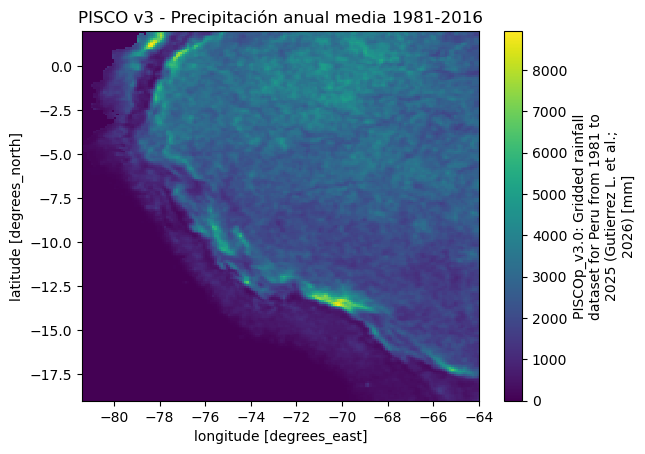

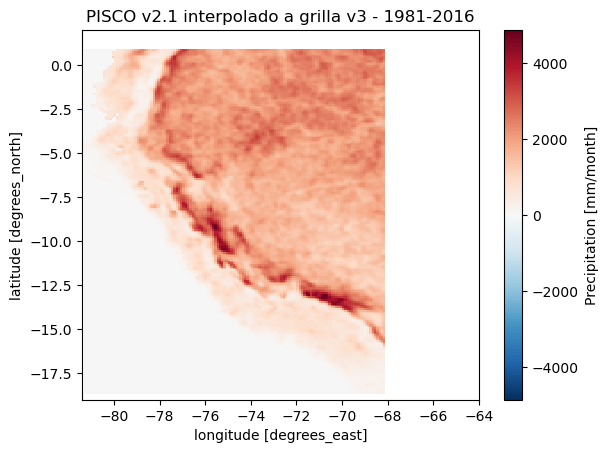

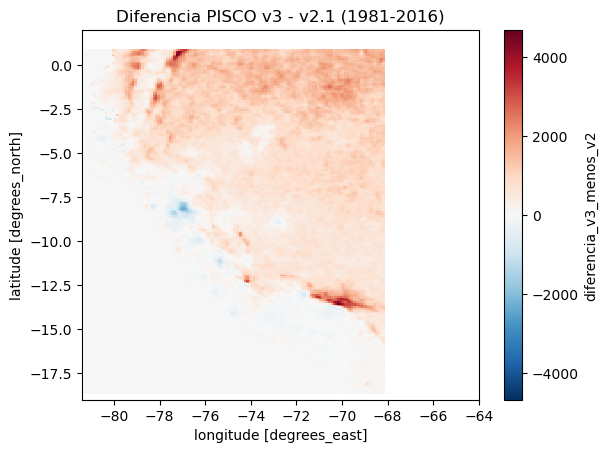

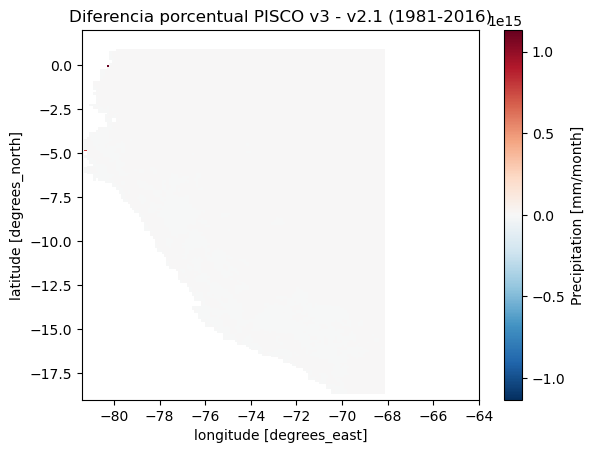

In [15]:
import matplotlib.pyplot as plt

clim_v3.plot()
plt.title(f"PISCO v3 - Precipitación anual media {anio_inicio}-{anio_fin}")
plt.show()

clim_v2_en_v3.plot()
plt.title(f"PISCO v2.1 interpolado a grilla v3 - {anio_inicio}-{anio_fin}")
plt.show()

diferencia.plot()
plt.title(f"Diferencia PISCO v3 - v2.1 ({anio_inicio}-{anio_fin})")
plt.show()

diferencia_pct.plot()
plt.title(f"Diferencia porcentual PISCO v3 - v2.1 ({anio_inicio}-{anio_fin})")
plt.show()

In [16]:
# ----------------------------------------
# RANGO COMÚN
# ----------------------------------------
vmin = min(
    float(clim_v3.min()),
    float(clim_v2_en_v3.min())
)

vmax = max(
    float(clim_v3.max()),
    float(clim_v2_en_v3.max())
)

print(vmin, vmax)

-5.50021998049071e-06 8944.26953125


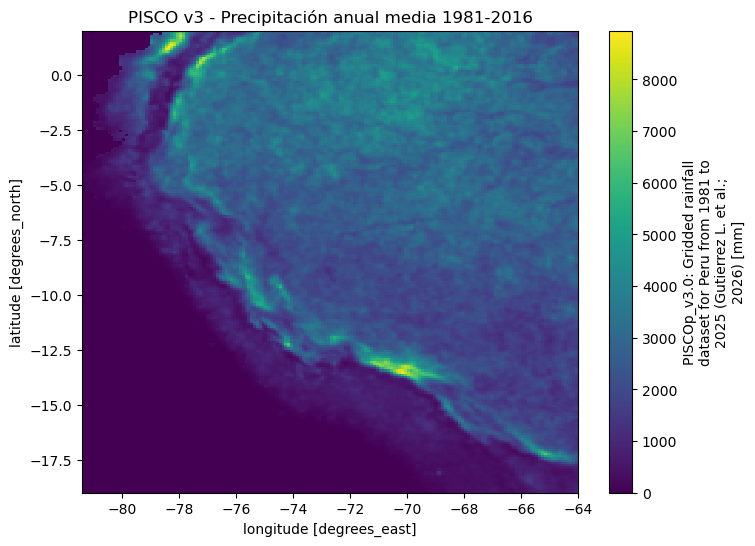

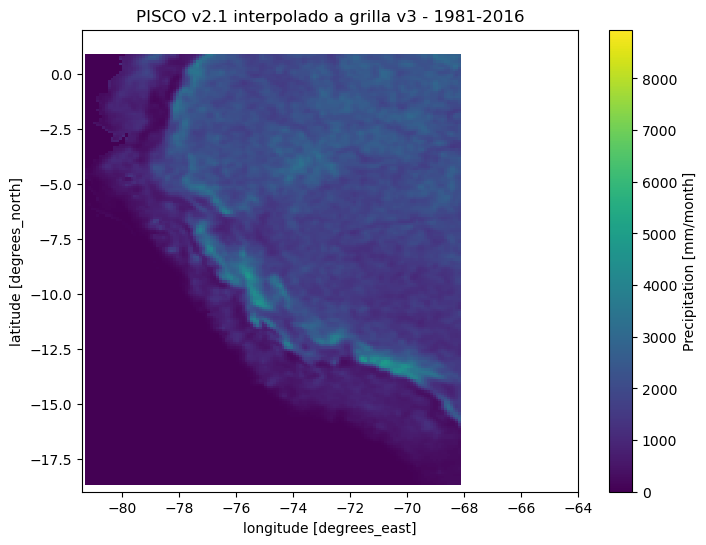

In [17]:
# ----------------------------------------
# V3
# ----------------------------------------
plt.figure(figsize=(8,6))

clim_v3.plot(
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

plt.title("PISCO v3 - Precipitación anual media 1981-2016")
plt.show()


# ----------------------------------------
# V2 interpolado
# ----------------------------------------
plt.figure(figsize=(8,6))

clim_v2_en_v3.plot(
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

plt.title("PISCO v2.1 interpolado a grilla v3 - 1981-2016")
plt.show()

In [18]:
def comparar_series_pisco(
    ds_v2,
    ds_v3,
    lon,
    lat,
    anio_inicio,
    anio_fin,
    var="prec",
    metodo_interp="nearest"
):
    """
    Extrae y compara series temporales mensuales de precipitación
    entre PISCO v2 y v3 para un punto específico.

    Parámetros
    ----------
    ds_v2 : xarray.Dataset
        Dataset PISCO v2 estandarizado.

    ds_v3 : xarray.Dataset
        Dataset PISCO v3 estandarizado.

    lon : float
        Longitud del punto.

    lat : float
        Latitud del punto.

    anio_inicio : int
        Año inicial.

    anio_fin : int
        Año final.

    var : str
        Nombre de la variable de precipitación.

    metodo_interp : str
        Método de selección espacial:
        "nearest" o "linear"

    Retorna
    -------
    pandas.DataFrame
        Columnas:
        - time
        - lon
        - lat
        - precip_v2
        - precip_v3
    """

    # ---------------------------------------------------------
    # RECORTE TEMPORAL
    # ---------------------------------------------------------
    fecha_inicio = f"{anio_inicio}-01-01"
    fecha_fin = f"{anio_fin}-12-31"

    ds_v2_sel = ds_v2.sel(time=slice(fecha_inicio, fecha_fin))
    ds_v3_sel = ds_v3.sel(time=slice(fecha_inicio, fecha_fin))

    # ---------------------------------------------------------
    # EXTRACCIÓN ESPACIAL
    # ---------------------------------------------------------
    if metodo_interp == "nearest":

        serie_v2 = ds_v2_sel[var].sel(
            lon=lon,
            lat=lat,
            method="nearest"
        )

        serie_v3 = ds_v3_sel[var].sel(
            lon=lon,
            lat=lat,
            method="nearest"
        )

    elif metodo_interp == "linear":

        serie_v2 = ds_v2_sel[var].interp(
            lon=lon,
            lat=lat,
            method="linear"
        )

        serie_v3 = ds_v3_sel[var].interp(
            lon=lon,
            lat=lat,
            method="linear"
        )

    else:
        raise ValueError(
            "metodo_interp debe ser 'nearest' o 'linear'"
        )

    # ---------------------------------------------------------
    # DATAFRAME
    # ---------------------------------------------------------
    df = pd.DataFrame({
        "time": serie_v3.time.values,
        "lon": lon,
        "lat": lat,
        "precip_v2": serie_v2.values,
        "precip_v3": serie_v3.values
    })

    return df

In [19]:
df_comp = comparar_series_pisco(
    ds_v2_std,
    ds_v3_std,
    lon=-77.04,
    lat=-12.05,
    anio_inicio=1981,
    anio_fin=2016,
    metodo_interp="nearest"
)

print(df_comp.head())

        time    lon    lat  precip_v2  precip_v3
0 1981-01-01 -77.04 -12.05   1.678342   0.958256
1 1981-02-01 -77.04 -12.05   0.000000   0.743028
2 1981-03-01 -77.04 -12.05   0.052652   0.004753
3 1981-04-01 -77.04 -12.05   0.255774   0.117663
4 1981-05-01 -77.04 -12.05   0.304323   0.603998


In [20]:
def graficar_comparacion_pisco(df_comp):
    df = df_comp.copy()
    df["time"] = pd.to_datetime(df["time"])

    df["diferencia_v3_menos_v2"] = df["precip_v3"] - df["precip_v2"]
    df["diferencia_pct"] = 100 * df["diferencia_v3_menos_v2"] / df["precip_v2"]

    df["diferencia_pct"] = df["diferencia_pct"].replace([np.inf, -np.inf], np.nan)

    # Serie mensual
    plt.figure(figsize=(13, 5))
    plt.plot(df["time"], df["precip_v2"], label="PISCO v2.1")
    plt.plot(df["time"], df["precip_v3"], label="PISCO v3")
    plt.title("Comparación mensual de precipitación")
    plt.ylabel("Precipitación mensual [mm]")
    plt.xlabel("Tiempo")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Diferencia absoluta
    plt.figure(figsize=(13, 4))
    plt.axhline(0, linewidth=1)
    plt.plot(df["time"], df["diferencia_v3_menos_v2"])
    plt.title("Diferencia mensual: PISCO v3 - PISCO v2.1")
    plt.ylabel("Diferencia [mm]")
    plt.xlabel("Tiempo")
    plt.grid(True)
    plt.show()

    # Diferencia porcentual
    plt.figure(figsize=(13, 4))
    plt.axhline(0, linewidth=1)
    plt.plot(df["time"], df["diferencia_pct"])
    plt.title("Diferencia porcentual mensual: PISCO v3 - PISCO v2.1")
    plt.ylabel("Diferencia [%]")
    plt.xlabel("Tiempo")
    plt.grid(True)
    plt.show()

    return df

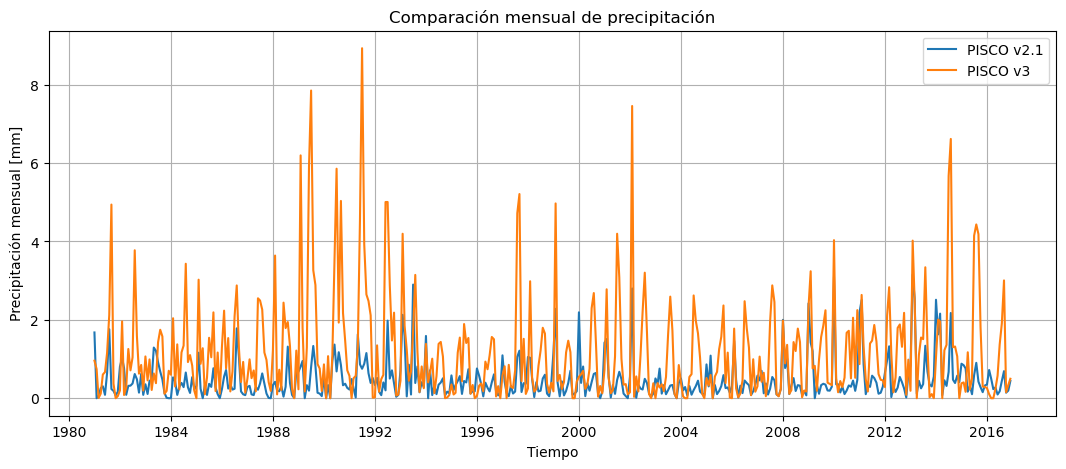

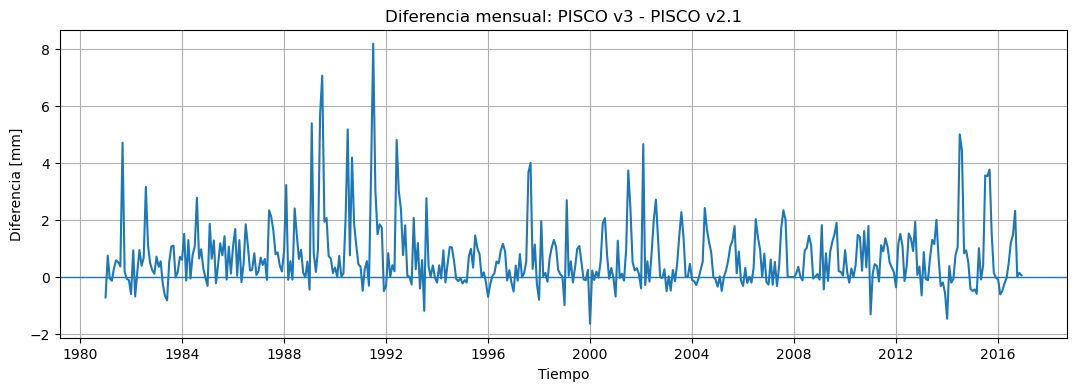

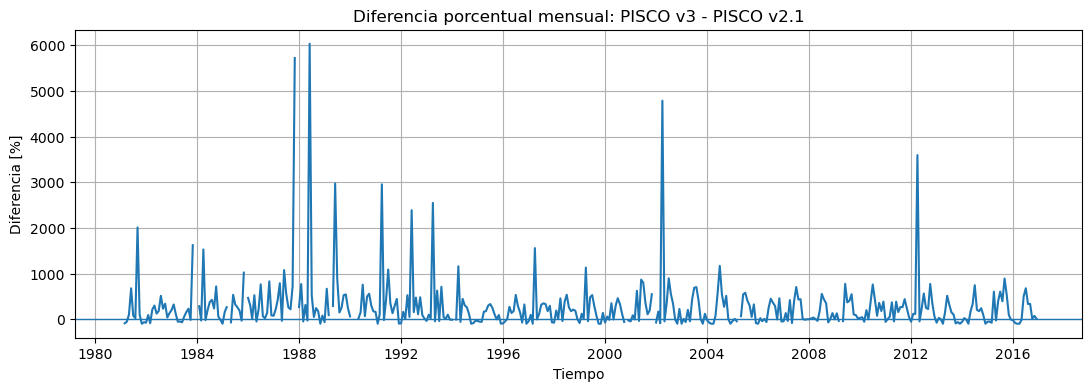

In [21]:
df_comp_graf = graficar_comparacion_pisco(df_comp)